# EmoExpress: GoEmotions Exploration, Preprocessing, and Emotion Classification

## Objective
This notebook provides the complete emotion-classification workflow in one place:

1. Load and inspect the **GoEmotions** dataset.
2. Perform concise data exploration and preprocessing.
3. Prepare multi-label targets for traditional ML, Bi-LSTM, and transformer models.
4. Train/evaluate five models:
   - TF-IDF + Logistic Regression
   - TF-IDF + Linear SVM
   - Bi-LSTM
   - Fine-tuned DistilBERT
   - Pretrained RoBERTa
5. Compare model performance using classification reports and Hamming loss.

## 1. Imports and project configuration


In [1]:
from pathlib import Path
from collections import Counter
import gc
import json
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

from datasets import load_dataset, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, hamming_loss

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in [PROCESSED_DATA_DIR, MODEL_DIR, METRICS_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cpu


## 2. Load and inspect GoEmotions


In [2]:
DATASET_NAME = "google-research-datasets/go_emotions"
DATASET_CONFIG = "simplified"

goemotions = load_dataset(DATASET_NAME, DATASET_CONFIG)
goemotions


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

**Observation**
- The dataset includes 3 splits: train, validation and test split. 
- The total 54,263 text examples.
- There are 3 features of each split: text, labels and id.

In [3]:
print(goemotions)
print("Columns:", goemotions["train"].column_names)
print("Features:", goemotions["train"].features)

for index in range(3):
    sample = goemotions["train"][index]
    print(f"\nExample {index + 1}")
    print("Text:", sample["text"])
    print("Label IDs:", sample["labels"])


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
Columns: ['text', 'labels', 'id']
Features: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

Example 1
Text: My favourite food is anything I didn't have to cook myself.
Label IDs: [27]

Example 2
Text: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Label ID

**Observation**
- For each text, it is classified by one emotion id which matches with the labels' feature. Thus, we need to decode the label id to its label's name. 

### Decode emotion labels


In [4]:
label_feature = goemotions["train"].features["labels"].feature
label_names = label_feature.names
num_labels = len(label_names)

id2label = {index: label for index, label in enumerate(label_names)}
label2id = {label: index for index, label in id2label.items()}

def decode_emotions(label_ids):
    return [label_names[int(label_id)] for label_id in label_ids]

print("Number of labels:", num_labels)
print(label_names)

for index in range(3):
    sample = goemotions["train"][index]
    print(sample["text"])
    print("Emotions:", decode_emotions(sample["labels"]))
    print("-" * 80)


Number of labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
My favourite food is anything I didn't have to cook myself.
Emotions: ['neutral']
--------------------------------------------------------------------------------
Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Emotions: ['neutral']
--------------------------------------------------------------------------------
WHY THE FUCK IS BAYLESS ISOING
Emotions: ['anger']
--------------------------------------------------------------------------------


**Observation**
- There are 28 labels in the dataset.

## 3. Convert splits and perform concise data exploration


In [5]:
train_df = goemotions["train"].to_pandas()
validation_df = goemotions["validation"].to_pandas()
test_df = goemotions["test"].to_pandas()

for dataframe in [train_df, validation_df, test_df]:
    dataframe["emotion_names"] = dataframe["labels"].apply(decode_emotions)
    dataframe["label_count"] = dataframe["labels"].apply(len)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)
display(train_df[["text", "labels", "emotion_names"]].head(3))


Train shape: (43410, 5)
Validation shape: (5426, 5)
Test shape: (5427, 5)


,text,labels,emotion_names
0,My favourite food is anything I didn't have to...,[27],[neutral]
1,"Now if he does off himself, everyone will thin...",[27],[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,[2],[anger]


**Observation**
- Each split is decoded to its labels name with another column inserted called emotion_names.

In [6]:
def summarize_split(dataframe, name):
    return {
        "split": name,
        "rows": len(dataframe),
        "missing_text": int(dataframe["text"].isna().sum()),
        "empty_text": int(dataframe["text"].fillna("").str.strip().eq("").sum()),
        "duplicate_text": int(dataframe["text"].duplicated().sum()),
        "avg_labels_per_sample": round(dataframe["label_count"].mean(), 3),
    }

split_summary = pd.DataFrame([
    summarize_split(train_df, "train"),
    summarize_split(validation_df, "validation"),
    summarize_split(test_df, "test"),
])
display(split_summary)

print("Train-validation overlap:", len(set(train_df["text"]) & set(validation_df["text"])))
print("Train-test overlap:", len(set(train_df["text"]) & set(test_df["text"])))
print("Validation-test overlap:", len(set(validation_df["text"]) & set(test_df["text"])))


,split,rows,missing_text,empty_text,duplicate_text,avg_labels_per_sample
0,train,43410,0,0,183,1.177
1,validation,5426,0,0,3,1.176
2,test,5427,0,0,6,1.166


Train-validation overlap: 41
Train-test overlap: 32
Validation-test overlap: 10


**Observation**
- There is no missing text in each split. 
- There are 183 duplicated text in train set, 3 duplicated text in validation and 6 duplicated text in test set.
- The number of text overlap between train and validation set is 41, between train and test set is 32, and between validation and test set is 10.
- There are one more labels for each text because the average labels length for each split is more than 1. 

### Label-count and emotion-frequency distributions


,samples
label_count,
1,36308
2,6541
3,532
4,28
5,1


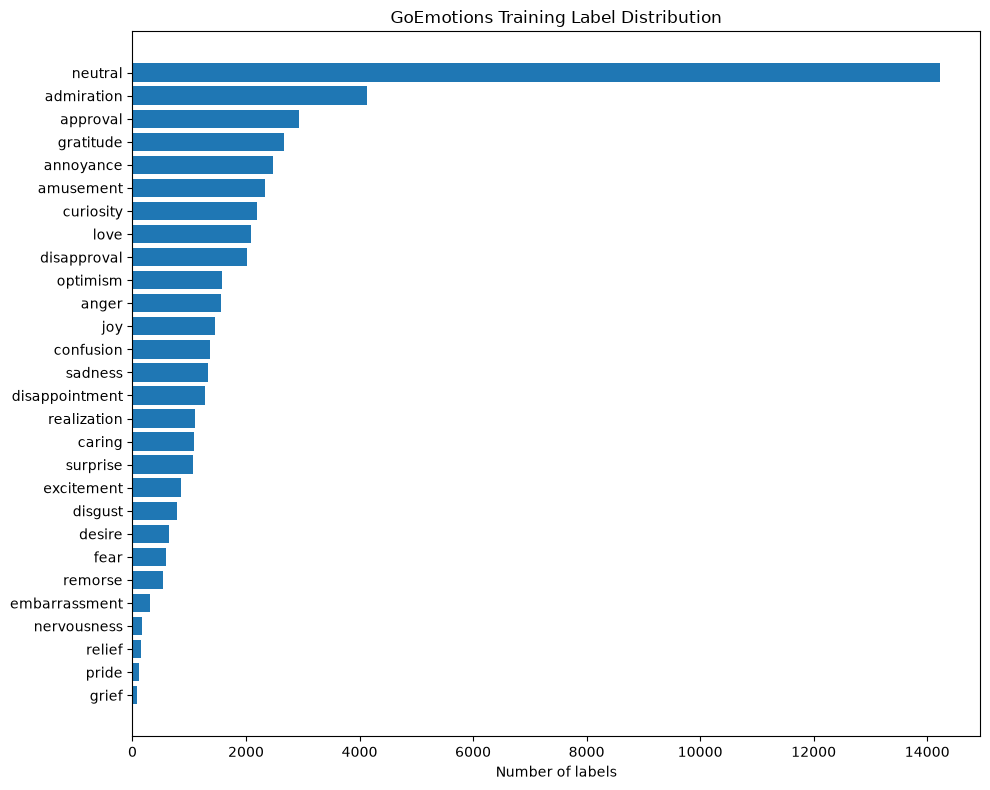

Most frequent emotions:


,emotion,count
0,neutral,14219
8,admiration,4130
11,approval,2939
5,gratitude,2662
3,annoyance,2470


Least frequent emotions:


,emotion,count
16,grief,77
26,pride,111
25,relief,153
27,nervousness,164
13,embarrassment,303


In [7]:
label_count_distribution = train_df["label_count"].value_counts().sort_index()
display(label_count_distribution.rename("samples").to_frame())

emotion_counts = Counter(
    emotion
    for labels in train_df["emotion_names"]
    for emotion in labels
)
train_emotion_counts = (
    pd.DataFrame(emotion_counts.items(), columns=["emotion", "count"])
    .sort_values("count", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(train_emotion_counts["emotion"], train_emotion_counts["count"])
plt.title("GoEmotions Training Label Distribution")
plt.xlabel("Number of labels")
plt.tight_layout()
plt.show()

print("Most frequent emotions:")
display(train_emotion_counts.sort_values("count", ascending=False).head(5))
print("Least frequent emotions:")
display(train_emotion_counts.head(5))


**Observation**
- The plot above shows the distribution of emotion labels which is imbalance. 
- The most distribution emotion is neutral. The least distribution emotion is grief.

### Text-length summary


In [8]:
train_df["word_count"] = train_df["text"].fillna("").str.split().str.len()
train_df["character_count"] = train_df["text"].fillna("").str.len()
display(train_df[["word_count", "character_count"]].describe())


,word_count,character_count
count,43410.000000,43410.000000
mean,12.840175,68.400875
std,6.701597,36.721898
min,1.000000,2.000000
25%,7.000000,38.000000
50%,12.000000,65.000000
75%,18.000000,96.000000
max,33.000000,703.000000


**Observation**
- The text-length distribution shows that most examples in GoEmotions are relatively short, while only a small number are much longer. This helped me understand the structure of the dataset and choose reasonable sequence lengths for preprocessing and model training

## 4. Preprocess text and build multi-hot targets

Traditional ML models use a lightly cleaned text column. Bi-LSTM and transformer models keep the original text so contextual information and punctuation are preserved.


In [9]:
def clean_text_for_ml(text):
    """Light cleaning for TF-IDF models while preserving useful negation/punctuation."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"/?u/\w+", " ", text)
    text = re.sub(r"[^a-z0-9\s'!?.,-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def create_multi_hot_vector(label_ids, number_of_labels=num_labels):
    vector = np.zeros(number_of_labels, dtype=np.int8)
    vector[[int(label_id) for label_id in label_ids]] = 1
    return vector.tolist()


for dataframe in [train_df, validation_df, test_df]:
    dataframe["clean_text_ml"] = dataframe["text"].apply(clean_text_for_ml)
    dataframe["label_vector"] = dataframe["labels"].apply(create_multi_hot_vector)

display(train_df[["text", "clean_text_ml", "emotion_names", "label_vector"]].head(3))
print("Label-vector length:", len(train_df.iloc[0]["label_vector"]))


,text,clean_text_ml,emotion_names,label_vector
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn't have to...,[neutral],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin...",[neutral],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,[anger],"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Label-vector length: 28


### Prepare target arrays and transformer dataset


In [10]:
y_train = np.asarray(train_df["label_vector"].tolist(), dtype=np.int8)
y_validation = np.asarray(validation_df["label_vector"].tolist(), dtype=np.int8)
y_test = np.asarray(test_df["label_vector"].tolist(), dtype=np.int8)

# Transformers can use the original Hugging Face DatasetDict directly.
dataset = goemotions

print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)
print("Unique target values:", np.unique(y_train))


y_train: (43410, 28)
y_validation: (5426, 28)
y_test: (5427, 28)
Unique target values: [0 1]


### Save processed data for reuse in other notebooks/app code


In [11]:
def prepare_dataframe_for_csv(dataframe):
    output = dataframe.copy()
    for column in ["labels", "emotion_names", "label_vector"]:
        output[column] = output[column].apply(
            lambda values: json.dumps([int(v) if isinstance(v, (np.integer,)) else v for v in list(values)])
        )
    return output

for split_name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    prepare_dataframe_for_csv(dataframe).to_csv(
        PROCESSED_DATA_DIR / f"goemotions_{split_name}.csv",
        index=False,
    )

with open(PROCESSED_DATA_DIR / "emotion_label_mapping.json", "w", encoding="utf-8") as file:
    json.dump({str(i): label for i, label in enumerate(label_names)}, file, indent=2)

print("Processed GoEmotions files saved to:", PROCESSED_DATA_DIR)


Processed GoEmotions files saved to: d:\FullStack_Academic\Final Capstone\EmoExpress\data\processed


## 5. Model input strategy

- **Logistic Regression / Linear SVM:** `clean_text_ml` + TF-IDF.
- **Bi-LSTM / DistilBERT / RoBERTa:** original `text`.
- **All models:** same 28-dimensional multi-hot targets and same predefined GoEmotions splits.
- **Threshold tuning:** intentionally not performed; neural/transformer sigmoid outputs use `0.50`.


## Shared evaluation function


In [12]:
def evaluate_multilabel_model(
    y_true,
    y_pred,
    model_name,
    target_names,
    training_time_seconds=None,
    inference_time_seconds=None,
):
    """
    Evaluate a multi-label model using classification_report
    and Hamming loss, then return the full summary row.
    """

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True,
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    model_hamming_loss = hamming_loss(
        y_true,
        y_pred,
    )

    print("=" * 100)
    print(model_name)
    print("=" * 100)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            zero_division=0,
        )
    )

    print(
        f"Hamming Loss: "
        f"{model_hamming_loss:.6f}"
    )

    summary = {
        "model": model_name,

        "micro_precision": float(
            report_df.loc[
                "micro avg",
                "precision",
            ]
        ),

        "micro_recall": float(
            report_df.loc[
                "micro avg",
                "recall",
            ]
        ),

        "micro_f1": float(
            report_df.loc[
                "micro avg",
                "f1-score",
            ]
        ),

        "macro_precision": float(
            report_df.loc[
                "macro avg",
                "precision",
            ]
        ),

        "macro_recall": float(
            report_df.loc[
                "macro avg",
                "recall",
            ]
        ),

        "macro_f1": float(
            report_df.loc[
                "macro avg",
                "f1-score",
            ]
        ),

        "weighted_f1": float(
            report_df.loc[
                "weighted avg",
                "f1-score",
            ]
        ),

        "samples_f1": float(
            report_df.loc[
                "samples avg",
                "f1-score",
            ]
        ),

        "hamming_loss": float(
            model_hamming_loss
        ),

        "training_time_seconds": (
            float(training_time_seconds)
            if training_time_seconds is not None
            else np.nan
        ),

        "inference_time_seconds": (
            float(inference_time_seconds)
            if inference_time_seconds is not None
            else np.nan
        ),
    }

    return report_df, summary


Initialize the model-comparison results list.


In [13]:
model_results = []


# Model 1: Logistic Regression


Use TF-IDF to convert text into numeric features.


In [14]:
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(
    train_df["clean_text_ml"].fillna("")
)

X_validation_tfidf = tfidf.transform(
    validation_df["clean_text_ml"].fillna("")
)

X_test_tfidf = tfidf.transform(
    test_df["clean_text_ml"].fillna("")
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)
print(
    "Validation TF-IDF shape:",
    X_validation_tfidf.shape
)
print(
    "Test TF-IDF shape:",
    X_test_tfidf.shape
)


Training TF-IDF shape: (43410, 20000)
Validation TF-IDF shape: (5426, 20000)
Test TF-IDF shape: (5427, 20000)


Train Logistic Regression


In [15]:
logistic_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    n_jobs=-1
)

start_time = time.time()

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_training_time = time.time() - start_time

print(
    "Training time:",
    round(logistic_training_time, 2),
    "seconds"
)


Training time: 21.48 seconds


### Logistic Regression classification report and Hamming loss


In [16]:
start_time = time.time()

logistic_test_predictions = logistic_model.predict(
    X_test_tfidf
)

logistic_inference_time = time.time() - start_time

(
    logistic_report_df,
    logistic_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=logistic_test_predictions,
    model_name="TF-IDF + Logistic Regression",
    target_names=label_names
)

logistic_results[
    "training_time_seconds"
] = float(logistic_training_time)

logistic_results[
    "inference_time_seconds"
] = float(logistic_inference_time)

model_results.append(logistic_results)

display(logistic_report_df)
pd.DataFrame([logistic_results])


TF-IDF + Logistic Regression
                precision    recall  f1-score   support

    admiration       0.51      0.74      0.60       504
     amusement       0.72      0.89      0.79       264
         anger       0.31      0.60      0.41       198
     annoyance       0.20      0.50      0.29       320
      approval       0.19      0.49      0.27       351
        caring       0.17      0.45      0.24       135
     confusion       0.22      0.63      0.32       153
     curiosity       0.29      0.60      0.39       284
        desire       0.30      0.54      0.38        83
disappointment       0.14      0.38      0.20       151
   disapproval       0.21      0.57      0.31       267
       disgust       0.35      0.59      0.44       123
 embarrassment       0.23      0.27      0.25        37
    excitement       0.18      0.53      0.27       103
          fear       0.50      0.71      0.59        78
     gratitude       0.85      0.91      0.88       352
         grief    

,precision,recall,f1-score,support
admiration,0.509537,0.742063,0.604200,504.0
amusement,0.720000,0.886364,0.794567,264.0
anger,0.308094,0.595960,0.406196,198.0
annoyance,0.203283,0.503125,0.289568,320.0
approval,0.188043,0.492877,0.272227,351.0
caring,0.166213,0.451852,0.243028,135.0
confusion,0.215078,0.633987,0.321192,153.0
curiosity,0.288364,0.602113,0.389966,284.0
desire,0.298013,0.542169,0.384615,83.0
disappointment,0.140394,0.377483,0.204668,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,TF-IDF + Logistic Regression,0.373737,0.68352,0.483244,0.344401,0.593893,0.424438,0.517716,0.509727,0.060886,21.482715,0.017105


# Model 2: TF-IDF + Linear SVM


Train Linear SVM


In [17]:
svm_model = OneVsRestClassifier(
    LinearSVC(
        class_weight="balanced"
    ),
    n_jobs=-1
)

start_time = time.time()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_training_time = time.time() - start_time

print(
    "Training time:",
    round(svm_training_time, 2),
    "seconds"
)


Training time: 6.46 seconds


### Evaluate Linear SVM

The model uses `predict()` with its default decision boundary of `0.0`. No threshold tuning is performed.


### Linear SVM classification report and Hamming loss


In [18]:
start_time = time.time()

svm_test_predictions = svm_model.predict(
    X_test_tfidf
)

svm_inference_time = time.time() - start_time

(
    svm_report_df,
    svm_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=svm_test_predictions,
    model_name="TF-IDF + Linear SVM",
    target_names=label_names
)

svm_results[
    "training_time_seconds"
] = float(svm_training_time)

svm_results[
    "inference_time_seconds"
] = float(svm_inference_time)

model_results.append(svm_results)

display(svm_report_df)
pd.DataFrame([svm_results])


TF-IDF + Linear SVM
                precision    recall  f1-score   support

    admiration       0.51      0.64      0.57       504
     amusement       0.69      0.80      0.74       264
         anger       0.35      0.44      0.39       198
     annoyance       0.20      0.35      0.26       320
      approval       0.19      0.36      0.25       351
        caring       0.23      0.31      0.26       135
     confusion       0.24      0.41      0.30       153
     curiosity       0.31      0.46      0.37       284
        desire       0.41      0.35      0.38        83
disappointment       0.17      0.24      0.20       151
   disapproval       0.22      0.37      0.28       267
       disgust       0.39      0.43      0.41       123
 embarrassment       0.21      0.14      0.16        37
    excitement       0.20      0.36      0.25       103
          fear       0.57      0.59      0.58        78
     gratitude       0.87      0.91      0.89       352
         grief       0.50  

,precision,recall,f1-score,support
admiration,0.511111,0.638889,0.567901,504.0
amusement,0.690789,0.795455,0.739437,264.0
anger,0.350806,0.439394,0.390135,198.0
annoyance,0.203670,0.346875,0.256647,320.0
approval,0.190193,0.364672,0.250000,351.0
caring,0.227027,0.311111,0.262500,135.0
confusion,0.240458,0.411765,0.303614,153.0
curiosity,0.305361,0.461268,0.367461,284.0
desire,0.408451,0.349398,0.376623,83.0
disappointment,0.174757,0.238411,0.201681,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,TF-IDF + Linear SVM,0.423045,0.570232,0.485734,0.384208,0.442389,0.399355,0.497055,0.485247,0.050291,6.45654,0.020386


# Model 3: Bi-LSTM


In [19]:
MAX_WORDS = 30000
MAX_LENGTH = 128

keras_tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

keras_tokenizer.fit_on_texts(
    train_df["text"]
)

X_train_sequences = keras_tokenizer.texts_to_sequences(
    train_df["text"]
)

X_validation_sequences = keras_tokenizer.texts_to_sequences(
    validation_df["text"]
)

X_test_sequences = keras_tokenizer.texts_to_sequences(
    test_df["text"]
)


In [20]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_validation_padded = pad_sequences(
    X_validation_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(X_train_padded.shape)


(43410, 128)


Build the Bi-LSTM


In [21]:
bilstm_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.4),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        num_labels,
        activation="sigmoid"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

bilstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the Bi-LSTM


In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

history = bilstm_model.fit(
    X_train_padded,
    y_train,

    validation_data=(
        X_validation_padded,
        y_validation
    ),

    epochs=8,
    batch_size=64,

    callbacks=[early_stopping]
)

bilstm_training_time = time.time() - start_time


Epoch 1/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - binary_accuracy: 0.9540 - loss: 0.1607 - val_binary_accuracy: 0.9618 - val_loss: 0.1261
Epoch 2/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 91s 134ms/step - binary_accuracy: 0.9640 - loss: 0.1214 - val_binary_accuracy: 0.9654 - val_loss: 0.1105
Epoch 3/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 91s 134ms/step - binary_accuracy: 0.9677 - loss: 0.1053 - val_binary_accuracy: 0.9660 - val_loss: 0.1067
Epoch 4/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 83s 122ms/step - binary_accuracy: 0.9702 - loss: 0.0932 - val_binary_accuracy: 0.9663 - val_loss: 0.1063
Epoch 5/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 76s 111ms/step - binary_accuracy: 0.9724 - loss: 0.0831 - val_binary_accuracy: 0.9657 - val_loss: 0.1098
Epoch 6/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 73s 107ms/step - binary_accuracy: 0.9748 - loss: 0.0746 - val_binary_accuracy: 0.9650 - val_loss: 0.1185


### Bi-LSTM classification report and Hamming loss


In [23]:
start_time = time.time()

bilstm_test_probabilities = bilstm_model.predict(
    X_test_padded,
    verbose=1
)

bilstm_inference_time = time.time() - start_time

bilstm_test_predictions = (
    bilstm_test_probabilities >= 0.50
).astype(int)

(
    bilstm_report_df,
    bilstm_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=bilstm_test_predictions,
    model_name="Bi-LSTM",
    target_names=label_names
)

bilstm_results[
    "training_time_seconds"
] = float(bilstm_training_time)

bilstm_results[
    "inference_time_seconds"
] = float(bilstm_inference_time)

model_results.append(bilstm_results)

display(bilstm_report_df)
pd.DataFrame([bilstm_results])


170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
Bi-LSTM
                precision    recall  f1-score   support

    admiration       0.65      0.55      0.60       504
     amusement       0.81      0.68      0.74       264
         anger       0.51      0.16      0.24       198
     annoyance       0.00      0.00      0.00       320
      approval       0.90      0.07      0.14       351
        caring       0.43      0.02      0.04       135
     confusion       0.00      0.00      0.00       153
     curiosity       0.47      0.10      0.16       284
        desire       0.79      0.13      0.23        83
disappointment       0.00      0.00      0.00       151
   disapproval       0.00      0.00      0.00       267
       disgust       0.00      0.00      0.00       123
 embarrassment       0.00      0.00      0.00        37
    excitement       1.00      0.03      0.06       103
          fear       0.00      0.00      0.00        78
     gratitude       0.95      0.89      0.92       3

,precision,recall,f1-score,support
admiration,0.650350,0.553571,0.598071,504.0
amusement,0.807175,0.681818,0.739220,264.0
anger,0.508197,0.156566,0.239382,198.0
annoyance,0.000000,0.000000,0.000000,320.0
approval,0.896552,0.074074,0.136842,351.0
caring,0.428571,0.022222,0.042254,135.0
confusion,0.000000,0.000000,0.000000,153.0
curiosity,0.465517,0.095070,0.157895,284.0
desire,0.785714,0.132530,0.226804,83.0
disappointment,0.000000,0.000000,0.000000,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Bi-LSTM,0.676444,0.357086,0.467425,0.392486,0.20362,0.237302,0.39587,0.388484,0.033891,512.034302,3.931311


# Model 4: Fine-tuned DistilBERT


Clear memory from Bi-LSTM


In [24]:
import gc   
tf.keras.backend.clear_session()
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Device: cpu


### Load transformer utilities


In [25]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)


### Define DistilBERT configuration


In [26]:
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"
print("Base model:", DISTILBERT_MODEL_NAME)
print("Number of labels:", num_labels)


Base model: distilbert-base-uncased
Number of labels: 28


Load the DistilBERT tokenizer


In [27]:
distilbert_tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_MODEL_NAME
)


Tokenize and encode labels


Preprocessing function:
- Tokenize each text.
- Convert label IDs such as [2, 15] into a 28-position multi-hot vector.
- Store the vector as floating-point values for binary cross-entropy.


In [28]:
MAX_TRANSFORMER_LENGTH = 128


def tokenize_goemotions_batch(batch):
    tokenized_batch = distilbert_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TRANSFORMER_LENGTH
    )

    multi_hot_labels = []

    for example_labels in batch["labels"]:
        label_vector = [0.0] * num_labels

        for label_id in example_labels:
            label_vector[int(label_id)] = 1.0

        multi_hot_labels.append(label_vector)

    tokenized_batch["labels"] = multi_hot_labels

    return tokenized_batch


Apply it to all splits


In [29]:
distilbert_dataset = dataset.map(
    tokenize_goemotions_batch,
    batched=True,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing GoEmotions for DistilBERT"
)

distilbert_dataset


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5427
    })
})

In [30]:
print(distilbert_dataset["train"][0].keys())
print(distilbert_dataset["train"][0]["labels"])
print(
    "Number of values in label vector:",
    len(distilbert_dataset["train"][0]["labels"])
)


dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Number of values in label vector: 28


Create the padding collator. Dynamic padding pads each batch only to its longest sequence rather than padding every example to 128 tokens.


In [31]:
class MultiLabelDataCollator(DataCollatorWithPadding):
    def __call__(self, features):
        labels = [
            feature.pop("labels")
            for feature in features
        ]

        batch = super().__call__(features)

        batch["labels"] = torch.tensor(
            labels,
            dtype=torch.float32
        )

        return batch


In [32]:
distilbert_data_collator = MultiLabelDataCollator(
    tokenizer=distilbert_tokenizer,
    return_tensors="pt"
)


Load DistilBERT for multi-label classification


In [33]:
distilbert_model = (
    AutoModelForSequenceClassification.from_pretrained(
        DISTILBERT_MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        problem_type="multi_label_classification"
    )
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [34]:
print("Problem type:",distilbert_model.config.problem_type)
print("Number of output labels:",distilbert_model.config.num_labels)


Problem type: multi_label_classification
Number of output labels: 28


### Define the sigmoid conversion function


In [35]:
def sigmoid_numpy(logits):
    logits = np.clip(logits, -50, 50)
    return 1.0 / (1.0 + np.exp(-logits))


Configure training


In [36]:
DISTILBERT_OUTPUT_DIR = (
    MODEL_DIR
    / "distilbert-goemotions-checkpoints"
)

distilbert_training_args = TrainingArguments(
    output_dir=str(
        DISTILBERT_OUTPUT_DIR
    ),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
    data_seed=42
)


Create the Trainer


In [37]:
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_dataset["train"],
    eval_dataset=distilbert_dataset["validation"],
    processing_class=distilbert_tokenizer,
    data_collator=distilbert_data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)


Fine-tune DistilBERT


In [38]:
start_time = time.time()

distilbert_train_output = distilbert_trainer.train()

distilbert_training_time = (time.time() - start_time)

print("DistilBERT training time:",round(distilbert_training_time, 2),"seconds")


Epoch,Training Loss,Validation Loss
1,0.090026,0.089218
2,0.083026,0.083951
3,0.076115,0.083869


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT training time: 12228.25 seconds


Plot training and validation loss


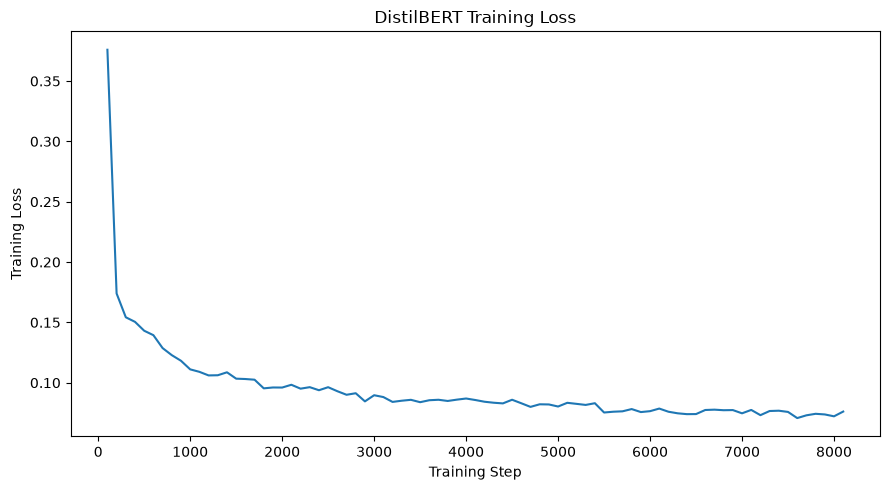

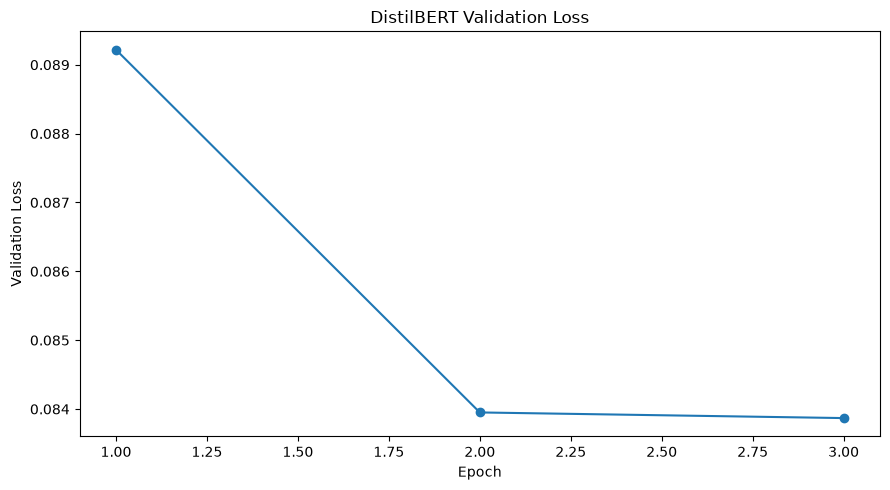

In [39]:
distilbert_log_history = pd.DataFrame(
    distilbert_trainer.state.log_history
)

distilbert_log_history.tail()
# Extract training loss:
train_loss_history = distilbert_log_history[
    distilbert_log_history["loss"].notna()
].copy()

validation_loss_history = distilbert_log_history[
    distilbert_log_history["eval_loss"].notna()
].copy()
# Plot training loss:
plt.figure(figsize=(9, 5))

plt.plot(
    train_loss_history["step"],
    train_loss_history["loss"]
)

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("DistilBERT Training Loss")
plt.tight_layout()
plt.show()
#Plot validation loss:
plt.figure(figsize=(9, 5))

plt.plot(
    validation_loss_history["epoch"],
    validation_loss_history["eval_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("DistilBERT Validation Loss")
plt.tight_layout()
plt.show()


### DistilBERT classification report and Hamming loss


In [40]:
start_time = time.time()

distilbert_test_output = distilbert_trainer.predict(
    distilbert_dataset["test"]
)

distilbert_inference_time = time.time() - start_time

print(
    "DistilBERT test inference time:",
    round(distilbert_inference_time, 2),
    "seconds"
)


DistilBERT test inference time: 140.61 seconds


In [41]:
distilbert_test_logits = distilbert_test_output.predictions

if isinstance(distilbert_test_logits, tuple):
    distilbert_test_logits = distilbert_test_logits[0]

distilbert_test_probabilities = sigmoid_numpy(
    distilbert_test_logits
)

distilbert_test_predictions = (
    distilbert_test_probabilities >= 0.50
).astype(int)

(
    distilbert_report_df,
    distilbert_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=distilbert_test_predictions,
    model_name="Fine-tuned DistilBERT",
    target_names=label_names
)

distilbert_results[
    "training_time_seconds"
] = float(distilbert_training_time)

distilbert_results[
    "inference_time_seconds"
] = float(distilbert_inference_time)

display(distilbert_report_df)
pd.DataFrame([distilbert_results])


Fine-tuned DistilBERT
                precision    recall  f1-score   support

    admiration       0.69      0.67      0.68       504
     amusement       0.81      0.84      0.82       264
         anger       0.62      0.37      0.47       198
     annoyance       0.57      0.13      0.21       320
      approval       0.61      0.26      0.37       351
        caring       0.52      0.24      0.33       135
     confusion       0.70      0.31      0.43       153
     curiosity       0.52      0.41      0.46       284
        desire       0.65      0.29      0.40        83
disappointment       0.83      0.10      0.18       151
   disapproval       0.53      0.24      0.33       267
       disgust       0.75      0.33      0.45       123
 embarrassment       0.60      0.08      0.14        37
    excitement       0.82      0.26      0.40       103
          fear       0.75      0.63      0.69        78
     gratitude       0.95      0.89      0.92       352
         grief       0.00

,precision,recall,f1-score,support
admiration,0.685484,0.674603,0.680000,504.0
amusement,0.807273,0.840909,0.823748,264.0
anger,0.616667,0.373737,0.465409,198.0
annoyance,0.567568,0.131250,0.213198,320.0
approval,0.605263,0.262108,0.365805,351.0
caring,0.524590,0.237037,0.326531,135.0
confusion,0.701493,0.307190,0.427273,153.0
curiosity,0.517857,0.408451,0.456693,284.0
desire,0.648649,0.289157,0.400000,83.0
disappointment,0.833333,0.099338,0.177515,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Fine-tuned DistilBERT,0.713124,0.485069,0.577393,0.592572,0.358218,0.418231,0.547537,0.521104,0.029574,12228.246817,140.607835


### Add DistilBERT to the model comparison


In [42]:
model_results = [ result  for result in model_results  if result["model"] != "Fine-tuned DistilBERT"]

model_results.append(distilbert_results)

# pd.DataFrame(model_results)


Save Model 4


In [43]:
DISTILBERT_FINAL_PATH = (
    MODEL_DIR
    / "distilbert-goemotions-final"
)

distilbert_trainer.save_model(
    str(DISTILBERT_FINAL_PATH)
)

distilbert_tokenizer.save_pretrained(
    str(DISTILBERT_FINAL_PATH)
)

# print(
#     "DistilBERT model saved to:",
#     DISTILBERT_FINAL_PATH
# )


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('d:\\FullStack_Academic\\Final Capstone\\EmoExpress\\models\\distilbert-goemotions-final\\tokenizer_config.json',
 'd:\\FullStack_Academic\\Final Capstone\\EmoExpress\\models\\distilbert-goemotions-final\\tokenizer.json')

In [44]:
distilbert_config_data = {
    "model_name": DISTILBERT_MODEL_NAME,
    "prediction_threshold": 0.50,
    "max_length": MAX_TRANSFORMER_LENGTH,
    "label_names": label_names
}

config_path = (
    DISTILBERT_FINAL_PATH
    / "emoexpress_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        distilbert_config_data,
        file,
        indent=4
    )

# print(
#     "Saved DistilBERT configuration:",
#     config_path
# )


# Model 5: Pretrained RoBERTa

This model uses `SamLowe/roberta-base-go_emotions`, which is already trained for the 28 GoEmotions labels.

It is evaluated without additional fine-tuning and uses the standard sigmoid threshold of `0.50`.


### Load the pretrained tokenizer and model


In [45]:
PRETRAINED_ROBERTA_MODEL = "SamLowe/roberta-base-go_emotions"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    PRETRAINED_ROBERTA_MODEL
)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_ROBERTA_MODEL
)

roberta_model.to(device)
roberta_model.eval()

print("Loaded:", PRETRAINED_ROBERTA_MODEL)
print("Number of output labels:", roberta_model.config.num_labels)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded: SamLowe/roberta-base-go_emotions
Number of output labels: 28


### Tokenize the GoEmotions test set


In [46]:
roberta_test_df = test_df[["text", "label_vector"]].copy()
roberta_test_df = roberta_test_df.rename(columns={"label_vector": "labels"})

roberta_test_dataset = Dataset.from_pandas(
    roberta_test_df,
    preserve_index=False,
)

print(roberta_test_dataset[0]["labels"])
print("Label-vector length:", len(roberta_test_dataset[0]["labels"]))


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
Label-vector length: 28


In [47]:
def tokenize_roberta_batch(batch):
    return roberta_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TRANSFORMER_LENGTH,
    )


roberta_test_dataset = roberta_test_dataset.map(
    tokenize_roberta_batch,
    batched=True,
)

roberta_test_dataset = (
    roberta_test_dataset.remove_columns(
        ["text"]
    )
)


Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [48]:
roberta_data_collator = MultiLabelDataCollator(
    tokenizer=roberta_tokenizer,
    padding=True,
)

roberta_training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / "pretrained-roberta-evaluation"),
    per_device_eval_batch_size=32,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    processing_class=roberta_tokenizer,
    data_collator=roberta_data_collator,
)

start_time = time.time()
roberta_test_output = roberta_trainer.predict(roberta_test_dataset)
roberta_inference_time = time.time() - start_time

roberta_test_logits = roberta_test_output.predictions
if isinstance(roberta_test_logits, tuple):
    roberta_test_logits = roberta_test_logits[0]

roberta_test_probabilities = sigmoid_numpy(roberta_test_logits)
roberta_test_predictions = (roberta_test_probabilities >= 0.50).astype(int)

roberta_report_df, roberta_results = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=roberta_test_predictions,
    model_name="Pretrained RoBERTa",
    target_names=label_names,
    training_time_seconds=0.0,
    inference_time_seconds=roberta_inference_time,
)

model_results.append(roberta_results)
display(roberta_report_df)
display(pd.DataFrame([roberta_results]))


Pretrained RoBERTa
                precision    recall  f1-score   support

    admiration       0.72      0.67      0.70       504
     amusement       0.79      0.87      0.83       264
         anger       0.65      0.38      0.48       198
     annoyance       0.47      0.16      0.24       320
      approval       0.61      0.30      0.40       351
        caring       0.45      0.32      0.37       135
     confusion       0.50      0.43      0.46       153
     curiosity       0.54      0.36      0.43       284
        desire       0.63      0.41      0.50        83
disappointment       0.62      0.20      0.30       151
   disapproval       0.49      0.31      0.38       267
       disgust       0.71      0.33      0.45       123
 embarrassment       0.75      0.24      0.37        37
    excitement       0.60      0.34      0.43       103
          fear       0.76      0.60      0.67        78
     gratitude       0.96      0.88      0.92       352
         grief       0.00   

,precision,recall,f1-score,support
admiration,0.724947,0.674603,0.698869,504.0
amusement,0.790378,0.871212,0.828829,264.0
anger,0.652174,0.378788,0.479233,198.0
annoyance,0.472222,0.159375,0.238318,320.0
approval,0.609195,0.301994,0.403810,351.0
caring,0.447917,0.318519,0.372294,135.0
confusion,0.500000,0.431373,0.463158,153.0
curiosity,0.537234,0.355634,0.427966,284.0
desire,0.629630,0.409639,0.496350,83.0
disappointment,0.625000,0.198675,0.301508,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Pretrained RoBERTa,0.684645,0.511455,0.585511,0.575237,0.396229,0.450315,0.56376,0.544401,0.03016,0.0,287.753628


# Compare All Five Models

The comparison uses values extracted from each model's classification report plus Hamming loss.

- Higher Micro F1, Macro F1, and Weighted F1 are better.
- Lower Hamming loss is better.


In [49]:
comparison_df = pd.DataFrame(model_results)

comparison_df = comparison_df.drop_duplicates(
    subset="model",
    keep="last"
)

comparison_df = comparison_df.sort_values(
    "micro_f1",
    ascending=False
).reset_index(drop=True)

comparison_df


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Pretrained RoBERTa,0.684645,0.511455,0.585511,0.575237,0.396229,0.450315,0.563760,0.544401,0.030160,0.000000,287.753628
1,Fine-tuned DistilBERT,0.713124,0.485069,0.577393,0.592572,0.358218,0.418231,0.547537,0.521104,0.029574,12228.246817,140.607835
2,TF-IDF + Linear SVM,0.423045,0.570232,0.485734,0.384208,0.442389,0.399355,0.497055,0.485247,0.050291,6.456540,0.020386
3,TF-IDF + Logistic Regression,0.373737,0.683520,0.483244,0.344401,0.593893,0.424438,0.517716,0.509727,0.060886,21.482715,0.017105
4,Bi-LSTM,0.676444,0.357086,0.467425,0.392486,0.203620,0.237302,0.395870,0.388484,0.033891,512.034302,3.931311


### Compare Micro F1


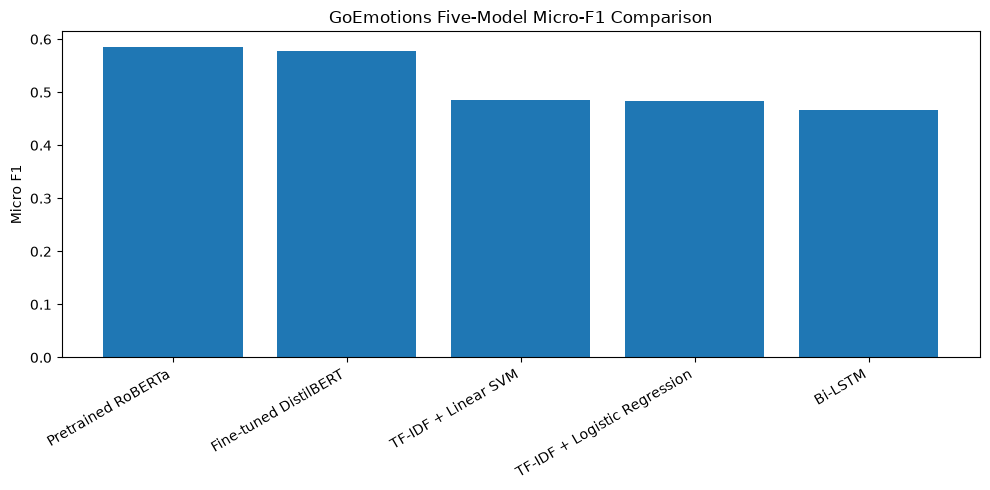

In [50]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["model"],
    comparison_df["micro_f1"]
)

plt.ylabel("Micro F1")
plt.title("GoEmotions Five-Model Micro-F1 Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Compare Macro F1 and Hamming loss


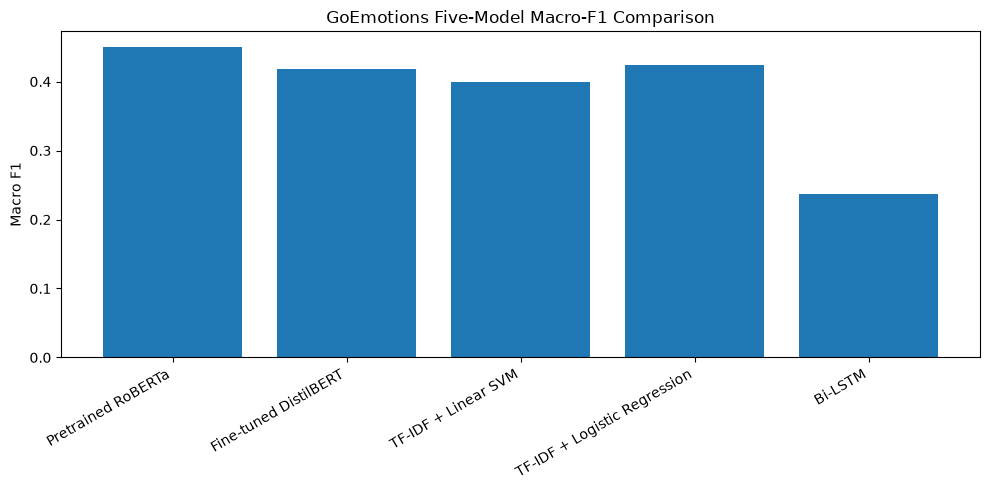

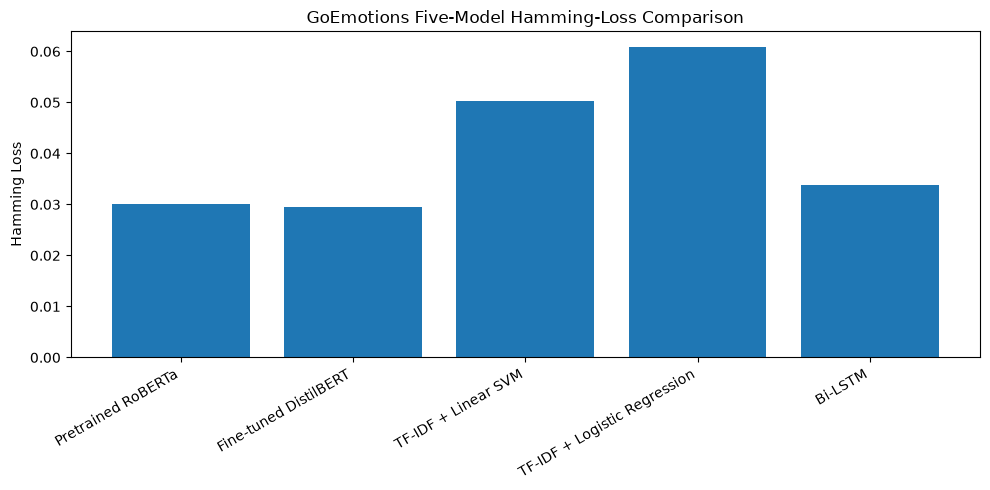

In [51]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["model"],
    comparison_df["macro_f1"]
)

plt.ylabel("Macro F1")
plt.title("GoEmotions Five-Model Macro-F1 Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["model"],
    comparison_df["hamming_loss"]
)

plt.ylabel("Hamming Loss")
plt.title("GoEmotions Five-Model Hamming-Loss Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Conclusion

In this notebook, I built the emotion classification component of EmoExpress using the GoEmotions dataset.

I first explored and preprocessed the dataset, cleaned the text, and converted the emotion labels into multi-label vectors. Then, I trained and evaluated five different models: Logistic Regression, Linear SVM, Bi-LSTM, fine-tuned DistilBERT, and pretrained RoBERTa.

For each model, I used precision, recall, and F1 to understand its performance in detail. When comparing the five models, I focused on Micro F1 for overall multi-label performance and Macro F1 to check performance across all emotion classes equally. In addition, I compared the models using Hamming Loss, and computation time too. The transformer models performed better overall, and pretrained RoBERTa achieved the highest Micro F1 score of 0.5855.

From this experiment, I learned how different NLP approaches handle multi-label emotion classification and the trade-off between model performance and computational cost. Based on the results, I selected pretrained RoBERTa as the final emotion classifier for the EmoExpress pipeline.

